In [4]:
import torch
import cv2
import numpy as np
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device="cuda")
predictor = SamPredictor(sam)

In [5]:
import os
import random

folder_path = "data/ATPfinal/test_images_2026022"
result_yaml = "sam_boxes.yaml"
mask_dir = "data/ATPfinal/masks"  # directory where ground truth masks are saved
os.makedirs(mask_dir, exist_ok=True)

# ── Load existing results (append mode) ─────────────────────────────────
existing_results = []
already_annotated = set()
if os.path.exists(result_yaml):
    try:
        import yaml
        with open(result_yaml, "r") as f:
            data = yaml.safe_load(f)
        if data and "results" in data:
            existing_results = data["results"]
            already_annotated = {r["image"] for r in existing_results}
            print(f"Loaded {len(existing_results)} existing annotations")
    except Exception:
        pass

def interactive_refine(predictor, image, input_box, disp, scale):
    """
    Show initial box mask, then let user click to refine.
    Left-click = positive point, Right-click = negative point.
    ENTER = accept, C = clear points and reset to box-only mask, ESC = skip.
    """
    pos_points = []
    neg_points = []
    window = "Refine mask (L=pos, R=neg, ENTER=accept, C=clear, ESC=skip)"

    x1, y1, x2, y2 = input_box

    def predict_mask():
        pts = pos_points + neg_points
        labels = [1] * len(pos_points) + [0] * len(neg_points)
        if pts:
            point_coords = np.array(pts)
            point_labels = np.array(labels)
            masks, scores, logits = predictor.predict(
                box=input_box,
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=False,
            )
        else:
            masks, scores, logits = predictor.predict(
                box=input_box,
                multimask_output=False,
            )
        mask = masks[np.argmax(scores)]
        # Clip to ROI
        roi = np.zeros_like(mask, dtype=bool)
        roi[y1:y2 + 1, x1:x2 + 1] = True
        return mask & roi, float(np.max(scores))

    def show_overlay(mask):
        overlay = image.copy()
        overlay[mask] = (255, 0, 0)
        vis = cv2.addWeighted(image, 0.6, overlay, 0.4, 0)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 255), 2)
        for (px, py) in pos_points:
            cv2.circle(vis, (px, py), 6, (0, 255, 0), -1)
            cv2.circle(vis, (px, py), 6, (0, 0, 0), 1)
        for (px, py) in neg_points:
            cv2.circle(vis, (px, py), 6, (0, 0, 255), -1)
            cv2.circle(vis, (px, py), 6, (0, 0, 0), 1)
        if scale < 1.0:
            vis = cv2.resize(vis, (disp.shape[1], disp.shape[0]))
        cv2.imshow(window, cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

    def on_mouse(event, mx, my, flags, param):
        if scale < 1.0:
            ox = int(mx / scale)
            oy = int(my / scale)
        else:
            ox, oy = mx, my
        if not (x1 <= ox <= x2 and y1 <= oy <= y2):
            return
        if event == cv2.EVENT_LBUTTONDOWN:
            pos_points.append((ox, oy))
            mask, _ = predict_mask()
            show_overlay(mask)
        elif event == cv2.EVENT_RBUTTONDOWN:
            neg_points.append((ox, oy))
            mask, _ = predict_mask()
            show_overlay(mask)

    current_mask, current_score = predict_mask()
    cv2.namedWindow(window, cv2.WINDOW_AUTOSIZE)
    cv2.setMouseCallback(window, on_mouse)
    show_overlay(current_mask)

    accepted = False
    while True:
        key = cv2.waitKey(0) & 0xFF
        if key in (13, 10):
            current_mask, current_score = predict_mask()
            accepted = True
            break
        elif key in (ord("c"), ord("C")):
            pos_points.clear()
            neg_points.clear()
            current_mask, current_score = predict_mask()
            show_overlay(current_mask)
        elif key == 27:
            break

    cv2.destroyWindow(window)
    if accepted:
        return current_mask, current_score, list(pos_points), list(neg_points)
    return None, None, [], []

N_SAMPLES = 20

# Collect image files (excluding already annotated ones)
exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
all_files = [
    os.path.join(folder_path, f)
    for f in os.listdir(folder_path)
    if os.path.splitext(f.lower())[1] in exts
    and os.path.isfile(os.path.join(folder_path, f))
    and os.path.join(folder_path, f) not in already_annotated
]
if not all_files:
    print(f"No new images to annotate in {folder_path} ({len(already_annotated)} already done)")
else:
    num_samples = min(N_SAMPLES, len(all_files))
    sample_files = random.sample(all_files, num_samples)
    print(f"Annotating {num_samples} new images ({len(already_annotated)} previously done)")

    new_results = []

    for img_path in sample_files:
        image = cv2.imread(img_path)
        if image is None:
            print(f"Skipping unreadable image: {img_path}")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        predictor.set_image(image)

        max_w, max_h = 1000, 800
        h_img, w_img = image.shape[:2]
        scale = min(max_w / w_img, max_h / h_img, 1.0)
        disp = image
        if scale < 1.0:
            disp = cv2.resize(image, (int(w_img * scale), int(h_img * scale)))

        roi = cv2.selectROI("Draw box", cv2.cvtColor(disp, cv2.COLOR_RGB2BGR), showCrosshair=True)
        cv2.destroyAllWindows()

        x, y, w, h = roi
        if w == 0 or h == 0:
            print(f"No box selected for {img_path}, skipping.")
            continue

        if scale < 1.0:
            x = int(x / scale)
            y = int(y / scale)
            w = int(w / scale)
            h = int(h / scale)

        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(w_img - 1, x + w)
        y2 = min(h_img - 1, y + h)
        input_box = np.array([x1, y1, x2, y2])

        mask_in, score, pos_pts, neg_pts = interactive_refine(
            predictor, image, input_box, disp, scale
        )

        if mask_in is None:
            print(f"Skipped {img_path}")
            continue

        basename = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(mask_dir, f"{basename}_mask.png")
        cv2.imwrite(mask_path, (mask_in.astype(np.uint8) * 255))

        new_results.append(
            {
                "image": img_path,
                "mask": mask_path,
                "box": [int(x1), int(y1), int(x2), int(y2)],
                "pos_points": [list(map(int, p)) for p in pos_pts],
                "neg_points": [list(map(int, p)) for p in neg_pts],
                "score": score,
            }
        )

    # Append new results to existing ones
    all_results = existing_results + new_results

    try:
        import yaml
        with open(result_yaml, "w", encoding="utf-8") as f:
            yaml.safe_dump({"results": all_results}, f, sort_keys=False)
    except Exception:
        with open(result_yaml, "w", encoding="utf-8") as f:
            f.write("results:\n")
            for item in all_results:
                f.write("  - image: \"{}\"\n".format(item["image"]))
                f.write("    mask: \"{}\"\n".format(item["mask"]))
                f.write("    box: [{}]\n".format(", ".join(str(v) for v in item["box"])))
                f.write("    pos_points: [{}]\n".format(", ".join(str(p) for p in item["pos_points"])))
                f.write("    neg_points: [{}]\n".format(", ".join(str(p) for p in item["neg_points"])))
                f.write("    score: {}\n".format(item["score"]))

    print(f"Added {len(new_results)} new annotations (total: {len(all_results)})")
    print(f"Masks saved to {mask_dir}/")

Loaded 10 existing annotations
Annotating 20 new images (10 previously done)
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Selec

Loaded 30 annotated samples
Dataset size: 30
Trainable parameters: 4,058,340
Epoch   1/50  loss: 0.0483
Epoch   5/50  loss: 0.0246
Epoch  10/50  loss: 0.0221
Epoch  15/50  loss: 0.0200
Epoch  20/50  loss: 0.0195
Epoch  25/50  loss: 0.0166
Epoch  30/50  loss: 0.0166
Epoch  35/50  loss: 0.0156
Epoch  40/50  loss: 0.0142
Epoch  45/50  loss: 0.0165
Epoch  50/50  loss: 0.0131

Saved fine-tuned mask decoder to sam_finetuned.pth
Final loss: 0.0131


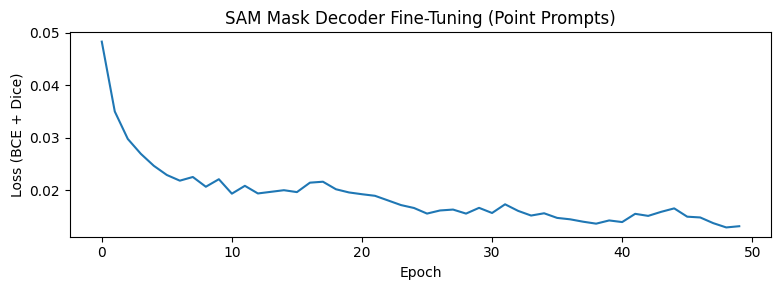

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import os

# ── Config ──────────────────────────────────────────────────────────────
result_yaml = "sam_boxes.yaml"
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
output_checkpoint = "sam_finetuned.pth"

lr = 1e-5
num_epochs = 50
batch_size = 1  # SAM processes one image at a time

# ── Load annotations ────────────────────────────────────────────────────
try:
    import yaml
    with open(result_yaml, "r") as f:
        data = yaml.safe_load(f)
except Exception:
    raise RuntimeError("Could not load sam_boxes.yaml – run Cell 2 first")

annotations = data["results"]
print(f"Loaded {len(annotations)} annotated samples")

# ── Dataset ─────────────────────────────────────────────────────────────
class SAMFineTuneDataset(Dataset):
    """Returns image, GT mask, and pos/neg point prompts for each annotation."""
    def __init__(self, annotations):
        self.annotations = annotations

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        image = cv2.imread(ann["image"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Ground-truth mask (saved as 0/255 PNG)
        gt_mask = cv2.imread(ann["mask"], cv2.IMREAD_GRAYSCALE)
        gt_mask = (gt_mask > 127).astype(np.float32)  # binary 0/1

        # Point prompts
        pos_points = [list(map(int, p)) for p in ann.get("pos_points", [])]
        neg_points = [list(map(int, p)) for p in ann.get("neg_points", [])]

        # If no positive points exist, generate one from the GT mask center of mass
        if not pos_points:
            ys, xs = np.where(gt_mask > 0.5)
            if len(xs) > 0:
                cx, cy = int(xs.mean()), int(ys.mean())
                pos_points = [[cx, cy]]

        return image, gt_mask, pos_points, neg_points

dataset = SAMFineTuneDataset(annotations)
print(f"Dataset size: {len(dataset)}")

# ── Load SAM & freeze image encoder ────────────────────────────────────
from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device="cuda")

# Freeze the image encoder (heavy ViT) – we only train mask decoder
for param in sam.image_encoder.parameters():
    param.requires_grad = False

# Optionally freeze prompt encoder too (usually fine to freeze)
for param in sam.prompt_encoder.parameters():
    param.requires_grad = False

# Only the mask decoder is trainable
trainable_params = [p for p in sam.mask_decoder.parameters() if p.requires_grad]
print(f"Trainable parameters: {sum(p.numel() for p in trainable_params):,}")

optimizer = torch.optim.Adam(trainable_params, lr=lr, weight_decay=1e-4)
transform = ResizeLongestSide(sam.image_encoder.img_size)

# ── Loss: BCE + Dice ────────────────────────────────────────────────────
def dice_loss(pred, target, smooth=1.0):
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    intersection = (pred_flat * target_flat).sum()
    return 1 - (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

def combined_loss(pred_mask, gt_mask):
    bce = F.binary_cross_entropy_with_logits(pred_mask, gt_mask)
    pred_sigmoid = torch.sigmoid(pred_mask)
    dice = dice_loss(pred_sigmoid, gt_mask)
    return bce + dice

# ── Training loop (point prompts only, no boxes) ────────────────────────
sam.train()
# Keep image encoder in eval mode (BatchNorm etc.)
sam.image_encoder.eval()

losses = []
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for i in range(len(dataset)):
        image_np, gt_mask_np, pos_pts, neg_pts = dataset[i]

        # Skip if no positive points at all
        if not pos_pts:
            continue

        # Prepare image for SAM
        input_image = transform.apply_image(image_np)
        input_image_torch = torch.as_tensor(input_image, dtype=torch.float32, device="cuda")
        input_image_torch = input_image_torch.permute(2, 0, 1).unsqueeze(0)  # 1,3,H,W
        input_image_torch = sam.preprocess(input_image_torch)

        # Encode image (no grad needed for frozen encoder)
        with torch.no_grad():
            image_embedding = sam.image_encoder(input_image_torch)

        # Prepare point prompts (no box)
        all_pts = pos_pts + neg_pts
        all_labels = [1] * len(pos_pts) + [0] * len(neg_pts)

        point_coords = np.array(all_pts, dtype=np.float32)
        point_labels = np.array(all_labels, dtype=np.int32)

        # Transform points to model input space
        point_coords_transformed = transform.apply_coords(point_coords, image_np.shape[:2])
        point_coords_torch = torch.as_tensor(
            point_coords_transformed, dtype=torch.float32, device="cuda"
        ).unsqueeze(0)  # 1, N, 2
        point_labels_torch = torch.as_tensor(
            point_labels, dtype=torch.int32, device="cuda"
        ).unsqueeze(0)  # 1, N

        sparse_embeddings, dense_embeddings = sam.prompt_encoder(
            points=(point_coords_torch, point_labels_torch),
            boxes=None,
            masks=None,
        )

        # Predict mask (mask decoder is trainable)
        low_res_masks, iou_predictions = sam.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )

        # Upscale predicted mask to original image size
        upscaled_mask = F.interpolate(
            low_res_masks,
            size=(sam.image_encoder.img_size, sam.image_encoder.img_size),
            mode="bilinear",
            align_corners=False,
        )
        # Crop to original image size
        h, w = image_np.shape[:2]
        new_h, new_w = transform.get_preprocess_shape(h, w, sam.image_encoder.img_size)
        upscaled_mask = upscaled_mask[..., :new_h, :new_w]
        upscaled_mask = F.interpolate(
            upscaled_mask, size=(h, w), mode="bilinear", align_corners=False
        )

        # Ground truth
        gt_mask_torch = torch.as_tensor(gt_mask_np, dtype=torch.float32, device="cuda")
        gt_mask_torch = gt_mask_torch.unsqueeze(0).unsqueeze(0)  # 1,1,H,W

        loss = combined_loss(upscaled_mask, gt_mask_torch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataset)
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs}  loss: {avg_loss:.4f}")

# ── Save fine-tuned weights ─────────────────────────────────────────────
torch.save(sam.mask_decoder.state_dict(), output_checkpoint)
print(f"\nSaved fine-tuned mask decoder to {output_checkpoint}")
print(f"Final loss: {losses[-1]:.4f}")

# Quick loss plot
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 3))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (BCE + Dice)")
    plt.title("SAM Mask Decoder Fine-Tuning (Point Prompts)")
    plt.tight_layout()
    plt.show()
except Exception:
    pass

In [ ]:
# import os
# import random
# import cv2
# import numpy as np
# import torch
# import yaml
# from segment_anything import sam_model_registry, SamPredictor

# # ── Config ──────────────────────────────────────────────────────────────
# folder_path = "data/ATPfinal/test_images_2026022"
# finetuned_checkpoint = "sam_finetuned.pth"
# sam_checkpoint = "sam_vit_h_4b8939.pth"
# model_type = "vit_h"
# num_images = 10  # how many images to evaluate

# # DeepLabV3 training data output
# deeplab_yaml = "deeplab_training.yaml"
# deeplab_mask_dir = "data/ATPfinal/deeplab_masks"
# os.makedirs(deeplab_mask_dir, exist_ok=True)

# # ── Load fine-tuned SAM ─────────────────────────────────────────────────
# sam_eval = sam_model_registry[model_type](checkpoint=sam_checkpoint)
# if os.path.exists(finetuned_checkpoint):
#     sam_eval.mask_decoder.load_state_dict(torch.load(finetuned_checkpoint, map_location="cpu"))
#     print("Loaded fine-tuned mask decoder")
# else:
#     print("WARNING: No fine-tuned checkpoint found, using base SAM")
# sam_eval.to(device="cuda")
# sam_eval.eval()
# eval_predictor = SamPredictor(sam_eval)

# # ── Load existing DeepLab training data (append mode) ───────────────────
# existing_deeplab = []
# already_generated = set()
# if os.path.exists(deeplab_yaml):
#     try:
#         with open(deeplab_yaml, "r") as f:
#             dl_data = yaml.safe_load(f)
#         if dl_data and "samples" in dl_data:
#             existing_deeplab = dl_data["samples"]
#             already_generated = {s["image"] for s in existing_deeplab}
#             print(f"Loaded {len(existing_deeplab)} existing DeepLab training samples")
#     except Exception:
#         pass

# # ── Pick random unannotated images ──────────────────────────────────────
# exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
# candidate_files = [
#     os.path.join(folder_path, f)
#     for f in os.listdir(folder_path)
#     if os.path.splitext(f.lower())[1] in exts
#     and os.path.isfile(os.path.join(folder_path, f))
#     and os.path.join(folder_path, f) not in already_generated
# ]
# if not candidate_files:
#     candidate_files = [
#         os.path.join(folder_path, f)
#         for f in os.listdir(folder_path)
#         if os.path.splitext(f.lower())[1] in exts
#         and os.path.isfile(os.path.join(folder_path, f))
#     ]

# num_images = min(num_images, len(candidate_files))
# sample_files = random.sample(candidate_files, num_images)
# print(f"Processing {num_images} images ({len(already_generated)} previously done)")
# print("For each image:")
# print("  1) Draw a bounding box around the object")
# print("  2) Left-click for positive points, Right-click for negative points")
# print("  3) Press ENTER to accept, C to clear points, ESC to skip")

# # ── Interactive point selection function ────────────────────────────────
# def interactive_point_selection(predictor, image, input_box, disp, scale):
#     """
#     Show initial box mask, then let user click to refine.
#     Left-click = positive point, Right-click = negative point.
#     ENTER = accept, C = clear points, ESC = skip.
#     """
#     pos_points = []
#     neg_points = []
#     window = "Refine mask (L=pos, R=neg, ENTER=accept, C=clear, ESC=skip)"

#     x1, y1, x2, y2 = input_box

#     def predict_mask():
#         pts = pos_points + neg_points
#         labels = [1] * len(pos_points) + [0] * len(neg_points)
#         if pts:
#             point_coords = np.array(pts)
#             point_labels = np.array(labels)
#             masks, scores, logits = predictor.predict(
#                 box=input_box,
#                 point_coords=point_coords,
#                 point_labels=point_labels,
#                 multimask_output=False,
#             )
#         else:
#             masks, scores, logits = predictor.predict(
#                 box=input_box,
#                 multimask_output=False,
#             )
#         mask = masks[np.argmax(scores)]
#         # Clip to ROI
#         roi = np.zeros_like(mask, dtype=bool)
#         roi[y1:y2 + 1, x1:x2 + 1] = True
#         return mask & roi, float(np.max(scores))

#     def show_overlay(mask):
#         overlay = image.copy()
#         overlay[mask] = (255, 0, 0)
#         vis = cv2.addWeighted(image, 0.6, overlay, 0.4, 0)
#         cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 255), 2)
#         for (px, py) in pos_points:
#             cv2.circle(vis, (px, py), 6, (0, 255, 0), -1)
#             cv2.circle(vis, (px, py), 6, (0, 0, 0), 1)
#         for (px, py) in neg_points:
#             cv2.circle(vis, (px, py), 6, (0, 0, 255), -1)
#             cv2.circle(vis, (px, py), 6, (0, 0, 0), 1)
#         if scale < 1.0:
#             vis = cv2.resize(vis, (disp.shape[1], disp.shape[0]))
#         cv2.imshow(window, cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

#     def on_mouse(event, mx, my, flags, param):
#         if scale < 1.0:
#             ox = int(mx / scale)
#             oy = int(my / scale)
#         else:
#             ox, oy = mx, my
#         if not (x1 <= ox <= x2 and y1 <= oy <= y2):
#             return
#         if event == cv2.EVENT_LBUTTONDOWN:
#             pos_points.append((ox, oy))
#             mask, _ = predict_mask()
#             show_overlay(mask)
#         elif event == cv2.EVENT_RBUTTONDOWN:
#             neg_points.append((ox, oy))
#             mask, _ = predict_mask()
#             show_overlay(mask)

#     current_mask, current_score = predict_mask()
#     cv2.namedWindow(window, cv2.WINDOW_AUTOSIZE)
#     cv2.setMouseCallback(window, on_mouse)
#     show_overlay(current_mask)

#     accepted = False
#     while True:
#         key = cv2.waitKey(0) & 0xFF
#         if key in (13, 10):  # ENTER
#             current_mask, current_score = predict_mask()
#             accepted = True
#             break
#         elif key in (ord("c"), ord("C")):  # Clear points
#             pos_points.clear()
#             neg_points.clear()
#             current_mask, current_score = predict_mask()
#             show_overlay(current_mask)
#         elif key == 27:  # ESC
#             break

#     cv2.destroyWindow(window)
#     if accepted:
#         return current_mask, current_score, list(pos_points), list(neg_points)
#     return None, None, [], []

# # ── Process each image: box → point prompts → SAM → accept/reject ──────
# max_w, max_h = 1000, 800
# new_samples = []
# grid_panels = []
# cell_size = 400

# for img_path in sample_files:
#     image_bgr = cv2.imread(img_path)
#     if image_bgr is None:
#         continue
#     image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
#     h_img, w_img = image_rgb.shape[:2]
#     scale = min(max_w / w_img, max_h / h_img, 1.0)
#     if scale < 1.0:
#         disp = cv2.resize(image_rgb, (int(w_img * scale), int(h_img * scale)))
#     else:
#         disp = image_rgb.copy()

#     eval_predictor.set_image(image_rgb)
#     fname = os.path.basename(img_path)
    
#     # Print filename to console instead of window title
#     print(f"\nAnnotating: {fname}")

#     # Draw bounding box - use simple ASCII window title
#     roi = cv2.selectROI("Draw box", cv2.cvtColor(disp, cv2.COLOR_RGB2BGR), showCrosshair=True)
#     cv2.destroyAllWindows()

#     x, y, w, h = roi
#     if w == 0 or h == 0:
#         print(f"  ✗ Skipped {fname} (no box selected)")
#         continue

#     # Convert display coordinates to original coordinates
#     if scale < 1.0:
#         x = int(x / scale)
#         y = int(y / scale)
#         w = int(w / scale)
#         h = int(h / scale)

#     x1 = max(0, x)
#     y1 = max(0, y)
#     x2 = min(w_img - 1, x + w)
#     y2 = min(h_img - 1, y + h)
#     input_box = np.array([x1, y1, x2, y2])

#     # Interactive point refinement
#     mask, score, pos_pts, neg_pts = interactive_point_selection(
#         eval_predictor, image_rgb, input_box, disp, scale
#     )

#     if mask is None:
#         print(f"  ✗ Skipped {fname}")
#         continue

#     # Save mask
#     basename = os.path.splitext(fname)[0]
#     mask_path = os.path.join(deeplab_mask_dir, f"{basename}_deeplab_mask.png")
#     cv2.imwrite(mask_path, (mask.astype(np.uint8) * 255))
#     new_samples.append({"image": img_path, "mask": mask_path})

#     # Prepare visualization
#     overlay = image_rgb.copy()
#     overlay[mask] = [255, 0, 0]
#     vis = cv2.addWeighted(image_rgb, 0.6, overlay, 0.4, 0)
#     cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 255), 2)
#     for (px, py) in pos_pts:
#         cv2.circle(vis, (px, py), 8, (0, 255, 0), -1)
#         cv2.circle(vis, (px, py), 8, (0, 0, 0), 2)
#     for (px, py) in neg_pts:
#         cv2.circle(vis, (px, py), 8, (0, 0, 255), -1)
#         cv2.circle(vis, (px, py), 8, (0, 0, 0), 2)

#     grid_vis = cv2.resize(vis, (cell_size, cell_size))
#     grid_panels.append(grid_vis)
#     print(f"  ✓ Accepted {fname}")

# # ── Save DeepLab training YAML ──────────────────────────────────────────
# all_deeplab = existing_deeplab + new_samples
# with open(deeplab_yaml, "w", encoding="utf-8") as f:
#     yaml.safe_dump({"samples": all_deeplab}, f, sort_keys=False)
# print(f"\nAdded {len(new_samples)} new samples (total: {len(all_deeplab)})")
# print(f"DeepLab masks saved to {deeplab_mask_dir}/")
# print(f"Training manifest: {deeplab_yaml}")

# # ── Show grid of accepted masks ────────────────────────────────────────
# if grid_panels:
#     ncols = 3
#     nrows = (len(grid_panels) + ncols - 1) // ncols
#     while len(grid_panels) < nrows * ncols:
#         grid_panels.append(np.zeros((cell_size, cell_size, 3), dtype=np.uint8))

#     rows = []
#     for r in range(nrows):
#         row = np.hstack(grid_panels[r * ncols : (r + 1) * ncols])
#         rows.append(row)
#     grid = np.vstack(rows)

#     cv2.imshow("Accepted masks for DeepLab (press any key)", cv2.cvtColor(grid, cv2.COLOR_RGB2BGR))
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()

# print("Done — run Cell 5 to train DeepLabV3")

Loaded fine-tuned mask decoder
Processing 10 images (0 previously done)
For each image:
  1) Draw a bounding box around the object
  2) Left-click for positive points, Right-click for negative points
  3) Press ENTER to accept, C to clear points, ESC to skip

Annotating: frame_000449.png
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
  ✓ Accepted frame_000449.png

Annotating: frame_000109.png
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
  ✓ Accepted frame_000109.png

Annotating: frame_000249.png
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
  ✓ Accepted frame_000249.png

Annotating: frame_000215.png
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
  ✓ Accepted frame_000215.png

Annotating: frame_000232.png
Select a ROI and then press SPACE or ENTER button!
Cancel the s

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models.segmentation import deeplabv3_resnet50
import cv2
import numpy as np
import os
import yaml
import random

# ── Config ──────────────────────────────────────────────────────────────
sam_yaml = "sam_boxes.yaml"  # generated by Cell 2
seg_checkpoint = "segmentation_model.pth"
img_size = (512, 512)  # resize for training
lr = 1e-4
num_epochs = 100
batch_size = 2
val_split = 0.2  # fraction for validation

# ── Load training data from SAM annotations ─────────────────────────────
with open(sam_yaml, "r") as f:
    data = yaml.safe_load(f)
annotations = data["results"]
print(f"Loaded {len(annotations)} training samples from {sam_yaml}")

random.shuffle(annotations)
n_val = max(1, int(len(annotations) * val_split))
train_anns = annotations[n_val:]
val_anns = annotations[:n_val]
print(f"Train: {len(train_anns)}, Val: {len(val_anns)}")

# ── Dataset with augmentation ───────────────────────────────────────────
class SegDataset(Dataset):
    def __init__(self, annotations, img_size, augment=False):
        self.annotations = annotations
        self.img_size = img_size
        self.augment = augment
        # ImageNet normalization for pretrained backbone
        self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        image = cv2.imread(ann["image"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(ann["mask"], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.uint8)

        # Augmentation (applied consistently to image + mask)
        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                image = cv2.flip(image, 1)
                mask = cv2.flip(mask, 1)
            # Random vertical flip
            if random.random() > 0.5:
                image = cv2.flip(image, 0)
                mask = cv2.flip(mask, 0)
            # Random rotation (±15°)
            angle = random.uniform(-15, 15)
            h, w = image.shape[:2]
            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
            mask = cv2.warpAffine(mask, M, (w, h), borderMode=cv2.BORDER_REFLECT)
            # Random brightness/contrast
            alpha = random.uniform(0.8, 1.2)
            beta = random.uniform(-20, 20)
            image = np.clip(alpha * image.astype(np.float32) + beta, 0, 255).astype(np.uint8)

        # Resize
        image = cv2.resize(image, self.img_size)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        # To tensor
        image_t = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        image_t = self.normalize(image_t)
        mask_t = torch.from_numpy(mask).float()  # H, W

        return image_t, mask_t

train_dataset = SegDataset(train_anns, img_size, augment=True)
val_dataset = SegDataset(val_anns, img_size, augment=False)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# ── Model: DeepLabV3 (pretrained ResNet-50, binary output) ──────────────
model = deeplabv3_resnet50(weights="DEFAULT")
# Replace classifier head for binary segmentation (1 output channel)
model.classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)
model.aux_classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)
model = model.to("cuda")

# ── Loss: BCE + Dice ────────────────────────────────────────────────────
def dice_loss(pred, target, smooth=1.0):
    pred_flat = pred.flatten(1)
    target_flat = target.flatten(1)
    intersection = (pred_flat * target_flat).sum(1)
    return (1 - (2.0 * intersection + smooth) / (pred_flat.sum(1) + target_flat.sum(1) + smooth)).mean()

def seg_loss(pred_logits, gt_mask):
    bce = F.binary_cross_entropy_with_logits(pred_logits, gt_mask)
    pred_sigmoid = torch.sigmoid(pred_logits)
    d = dice_loss(pred_sigmoid, gt_mask)
    return bce + d

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# ── Training loop ───────────────────────────────────────────────────────
train_losses, val_losses, val_ious = [], [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    epoch_loss = 0.0
    for images, masks in train_loader:
        images = images.to("cuda")
        masks = masks.to("cuda")

        out = model(images)["out"]  # B, 1, H, W
        pred = out.squeeze(1)  # B, H, W

        loss = seg_loss(pred, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * images.size(0)

    train_losses.append(epoch_loss / len(train_dataset))

    # Validate
    model.eval()
    val_loss = 0.0
    iou_sum = 0.0
    n_val_samples = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to("cuda")
            masks = masks.to("cuda")

            out = model(images)["out"].squeeze(1)
            loss = seg_loss(out, masks)
            val_loss += loss.item() * images.size(0)

            # IoU
            pred_bin = (torch.sigmoid(out) > 0.5).float()
            intersection = (pred_bin * masks).sum((1, 2))
            union = pred_bin.sum((1, 2)) + masks.sum((1, 2)) - intersection
            iou = (intersection + 1e-6) / (union + 1e-6)
            iou_sum += iou.sum().item()
            n_val_samples += images.size(0)

    val_losses.append(val_loss / max(n_val_samples, 1))
    val_ious.append(iou_sum / max(n_val_samples, 1))

    scheduler.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs}  "
              f"train_loss: {train_losses[-1]:.4f}  "
              f"val_loss: {val_losses[-1]:.4f}  "
              f"val_IoU: {val_ious[-1]:.4f}")

# ── Save model ──────────────────────────────────────────────────────────
torch.save(model.state_dict(), seg_checkpoint)
print(f"\nSaved segmentation model to {seg_checkpoint}")
print(f"Final val IoU: {val_ious[-1]:.4f}")

# ── Plot ────────────────────────────────────────────────────────────────
try:
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, label="Train")
    ax1.plot(val_losses, label="Val")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.set_title("Loss Curves")

    ax2.plot(val_ious)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("IoU")
    ax2.set_title("Validation IoU")

    plt.tight_layout()
    plt.show()
except Exception:
    pass

# ── Quick inference function (for deployment) ───────────────────────────
def predict_mask(image_path, model_path=seg_checkpoint, threshold=0.5):
    """
    Takes a raw image path, returns a binary mask.
    No prompts needed — fully automatic.
    """
    model = deeplabv3_resnet50(weights=None)
    model.classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)
    model.aux_classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.to("cuda")
    model.eval()

    normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = image_rgb.shape[:2]

    resized = cv2.resize(image_rgb, (512, 512))
    image_t = torch.from_numpy(resized).permute(2, 0, 1).float() / 255.0
    image_t = normalize(image_t).unsqueeze(0).to("cuda")

    with torch.no_grad():
        out = model(image_t)["out"].squeeze()
        mask = (torch.sigmoid(out) > threshold).cpu().numpy().astype(np.uint8)

    # Resize back to original resolution
    mask = cv2.resize(mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    return mask * 255

print("\nUsage: mask = predict_mask('path/to/image.png')")

Loaded 30 training samples from sam_boxes.yaml
Train: 24, Val: 6
Epoch   1/100  train_loss: 1.1615  val_loss: 0.7106  val_IoU: 0.7555
Epoch  10/100  train_loss: 0.4298  val_loss: 0.3854  val_IoU: 0.9370
